## Introduction to Data Science

#### University of Redlands - DATA 101
#### Prof: Joanna Bieri [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
#### [Class Website: data101.joannabieri.com](https://joannabieri.com/data101.html)

---------------------------------------
# Homework Day 8
---------------------------------------

GOALS:

1. Load data into Python that you find online
2. Understand data types and fix some errors
3. Find your own data to play with

----------------------------------------------------------

This homework has **5 questions** and **1 problem**.

NOTE: Be kind to yourself. Working with data can be hard! Every data set is different. **Seriously** come get help! Come to lab!


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

You might need to install lxml. If you get a "ImportError: Missing optional dependency 'lxml'" Then uncomment and run the cell below

In [13]:
!conda install -y lxml

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.



## Try reading in some data - csv

Go to the [Cal Fire Website](https://www.fire.ca.gov/incidents) and scroll to the bottom to see the Incident Data. We will download the file named **ALL DATA AS CSV** this should put the data file into your Downloads folder. 

Next you need to move the file **mapdataall.csv** from your Downloads folder into your Day8 folder where you are doing your homework. You can open your Downloads folder and drag the file into JupyterLab side bar. Then I can run the command

    DF_raw = pd.read_csv('mapdataall.csv')

to load the data and look at the data frame.

In [2]:
DF = pd.read_csv('mapdataall.csv')
DF
DF.keys()


Index(['incident_name', 'incident_is_final', 'incident_date_last_update',
       'incident_date_created', 'incident_administrative_unit',
       'incident_administrative_unit_url', 'incident_county',
       'incident_location', 'incident_acres_burned', 'incident_containment',
       'incident_control', 'incident_cooperating_agencies',
       'incident_longitude', 'incident_latitude', 'incident_type',
       'incident_id', 'incident_url', 'incident_date_extinguished',
       'incident_dateonly_extinguished', 'incident_dateonly_created',
       'is_active', 'calfire_incident', 'notification_desired'],
      dtype='object')

**Q1** How many variables and observations?

**Q2** How many different incident types are there?

**Q3** Make a histogram of the acres burned and color the bars by whether or not the incident was a calfire incident. You will probably need to make a mask to remove very small and very large fires. How many fires burned more than 100,000 acres? What is the largest fire in the data?

**Extra Q** EXTRA - CHALLENGE - See if you can create a graph that answers the question: Are fires getting bigger or more frequent over time? You get complete creative control on how to answer this question!

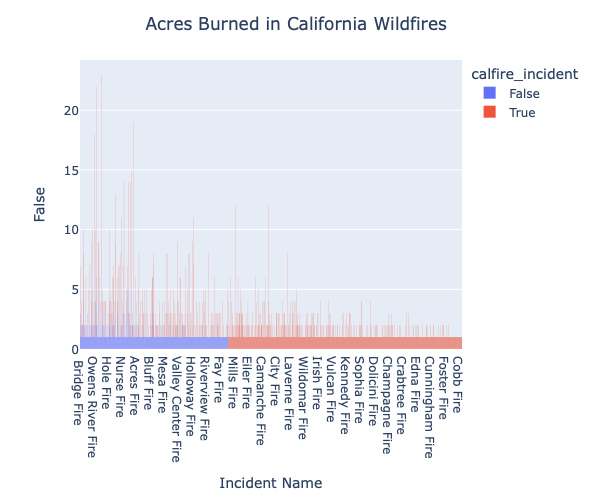

In [3]:
#Q1 - 23 variables across 3370 observations
#Q2
DF['incident_type'].value_counts()

#Q3

burn_columns = ['incident_name', 'calfire_incident', 'incident_acres_burned']
DF_burn = DF[burn_columns]
fig = px.histogram(DF_burn,
                  x='incident_name',
                  color= 'calfire_incident',
                  facet_col_wrap=1)

fig.update_layout(title='Acres Burned in California Wildfires',
                  title_x=0.5,
                  xaxis_title="Incident Name",
                  yaxis_title=False,
                  autosize=False,
                  width=800,
                  height=500)
fig.show()

#cal-fire incident


**(Click Here)**



In [12]:
# Extra Code


## Try reading in some data from Wikipedia - html

Here we will explore academy award winning films. Go to the [Wiki for the List of Academy Award Winning Films](https://en.wikipedia.org/wiki/List_of_Academy_Award%E2%80%93winning_films). Look at what type of data is there. How many tables? Any weird looking data?

Now we will read the html data into Python and show the data in DF[0]

In [4]:
# Here is some helper code
# This is code that will read in the data and then fix the Year column

#####
'''
NOTE: Many websites try to stop you from scraping even simple tables. 
    In just one year wikipedia made big changes... so I changed the code here.
    We can talk more about this code in class.
'''
import requests
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
my_website = "https://en.wikipedia.org/wiki/List_of_Academy_Award%E2%80%93winning_films"
response = requests.get(my_website, headers=headers)
#####

# Normal pandas code
DF = pd.read_html(response.content)
DF_raw = DF[0]
DF_raw['Year'] = DF_raw['Year'].apply(lambda x: int(x.split('/')[0]))
DF_raw

,Film,Year,Awards,Nominations
0,Anora,2024,5,6
1,The Brutalist,2024,3,10
2,Emilia Pérez,2024,2,13
3,Wicked,2024,2,10
4,Dune: Part Two,2024,2,5
...,...,...,...,...
1382,The Yankee Doodle Mouse,1943,1,1
1383,The Yearling,1946,2,7
1384,"Yesterday, Today and Tomorrow (Ieri, oggi, dom...",1964,1,1
1385,You Can't Take It with You,1938,2,7


**Q4** Following along with the lecture notes or video, fix the data in the 'Awards' column.

In [5]:
year_data = DF_raw['Year'].value_counts()
DF_year = year_data.reset_index().rename(columns={"index": "value", 0: "count"})
DF_year


,Year,count
0,1945,21
1,1949,20
2,1942,20
3,1941,19
4,1950,19
...,...,...
92,1931,10
93,1932,9
94,1928,7
95,1929,6


**Q5** Now try to fix the data in the "Nominations" column - see if you can do it without looking at the answer.

In [6]:
DF_raw['Nominations'] = DF_raw['Nominations'].apply(lambda x: x.split('[')[0])
DF_raw['Nominations'].value_counts()

Nominations
1     557
2     143
4     115
5     106
3     105
6      81
7      75
8      62
10     42
9      31
11     24
12     17
0      14
13     12
14      3
Name: count, dtype: int64

In [7]:
nom_data = DF_raw['Nominations'].value_counts()
DF_nom = nom_data.reset_index().rename(columns={"index": "value", 0: "count"})
DF_nom

,Nominations,count
0,1,557
1,2,143
2,4,115
3,5,106
4,3,105
5,6,81
6,7,75
7,8,62
8,10,42
9,9,31


## Problem 1

Your homework today will be to see if you can find some data of your own. This can be the first steps you take toward your final project. 

You should:

* Find some data online
* Read that data into Python using the Pandas commands we learned
* Look at the DataFrame - number of variables, number of observations, AND the dtypes. Comment on what you see.
* Try to do summary statistics (.describe()). Does it work like expected?
* Attempt to fix any data, or explain why the data does not need to be fixed.
* Make some sort of graph using columns in your data.

In [19]:
DF_CF = pd.read_excel('CrossFit_Games_Athletes_Women_2019.xlsx')
DF_CF
DF_CF.keys()
DF_CF.dtypes


height                 float64
affiliateid            float64
countryoforiginname     object
weight                 float64
affiliatename           object
status                  object
bibid                   object
profilepics3key         object
competitorid             int64
firstname               object
gender                  object
age                      int64
lastname                object
countryoforigincode     object
competitorname          object
overallrank             object
overallscore             int64
division                object
Number of Records        int64
dtype: object

In [16]:
DF_CF


,height,affiliateid,countryoforiginname,weight,affiliatename,status,bibid,profilepics3key,competitorid,firstname,gender,age,lastname,countryoforigincode,competitorname,overallrank,overallscore,division,Number of Records
0,1.65,44632.0,Australia,58.1,CrossFit Mayhem,ACT,17,b8a69-P163097_3-184.jpg,163097,Tia-Clair,F,25,Toomey,AU,Tia-Clair Toomey,1,1071,Women,1
1,1.65,44731.0,Norway,59.0,CrossFit Oslo,ACT,122,df164-P120480_7-184.jpg,120480,Kristin,F,33,Holte,NO,Kristin Holte,2,876,Women,1
2,1.65,44663.0,New Zealand,61.2,CrossFit Yas,ACT,123,101af-P264512_2-184.jpg,264512,Jamie,F,28,Greene,NZ,Jamie Greene,3,851,Women,1
3,1.74,44608.0,Iceland,68.0,CrossFit New England,ACT,15,ee582-P55121_22-184.jpg,55121,KatrÃ­n Tanja,F,26,Davidsdottir,IS,Katrin Tanja Davidsdottir,4,784,Women,1
4,1.62,44589.0,United States,63.0,CrossFit Spot,ACT,103,17c8c-P305891_3-184.jpg,305891,Karissa,F,30,Pearce,US,Karissa Pearce,5,714,Women,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,1.65,44947.0,United States,71.2,CrossFit Uncommon,ACT,610,433bb-P198927_3-184.jpg,198927,Julie,X,62,Holt,US,Julie Holt,6,380,Women (60+),1
187,1.62,44856.0,United States,53.1,Reebok CrossFit Medfield,ACT,605,a6012-P312883_7-184.jpg,312883,Carol Lynn,X,62,Thistle,US,Carol Lynn Thistle,7,310,Women (60+),1
188,1.25,44782.0,United States,50.8,Ft. Wright CrossFit,ACT,607,0b3ce-P32842_4-184.jpg,32842,Elizabeth,X,62,Cole,US,Elizabeth Cole,8,290,Women (60+),1
189,1.68,44821.0,Canada,57.2,CrossFit Living The Dream Ajax,ACT,606,10f1f-P702085_9-184.jpg,702085,Christine,X,60,Long,CA,Christine Long,9,250,Women (60+),1


This data has 190 observations and 19 variables.

In [18]:
DF_CF.describe()


,height,affiliateid,weight,competitorid,age,overallscore,Number of Records
count,191.000000,175.00000,191.000000,1.910000e+02,191.000000,191.000000,191.0
mean,1.620524,44763.12000,63.651309,4.135371e+05,35.005236,211.691099,1.0
std,0.258243,119.31318,5.680529,3.681899e+05,11.064166,249.065123,0.0
min,0.030000,44589.00000,50.800000,1.900000e+03,17.000000,-42.000000,1.0
25%,1.620000,44653.50000,59.000000,1.155655e+05,27.000000,-8.500000,1.0
50%,1.680000,44742.00000,63.500000,2.900010e+05,31.000000,125.000000,1.0
75%,1.710000,44881.50000,68.000000,6.629610e+05,41.000000,380.000000,1.0
max,1.800000,44970.00000,79.800000,1.521928e+06,62.000000,1071.000000,1.0


The affiliateid and competitorid are both being treated as numerical, but they don't need to be as there are identification numbers for atheltes and their affiliate gyms, not a number we want statistics on. I don't think this data needs any fixing. It is behaving as expected with the correct set up of rows and columns. The only thing that could be done is bringing athletes names first, but I think that doesn't have any statistical significance so it isn't necessary.

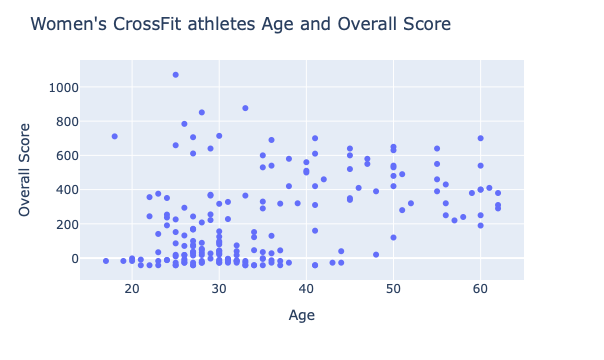

In [20]:
fig = px.scatter(DF_CF,
                 x = 'age',
                 y = 'overallscore')
fig.update_layout(title = "Women's CrossFit athletes Age and Overall Score",
                  xaxis_title= "Age",
                  yaxis_title= "Overall Score")
fig.show()
                  